# Assignment 2: Python for Text Processing

**Submission deadline:** Friday, 22 May 2026, 11:55 PM  
**Assessment marks:** 35 marks (35% of the total unit assessment)

---

### Late Submission Penalty

Unless a Special Consideration request has been submitted and approved, a 5% penalty (of the total possible mark of the task) will be applied for each day a written report or presentation assessment is not submitted, up until the 7th day (including weekends). After the 7th day, a grade of ‘0’ will be awarded even if the assessment is submitted.

> **Example:** If the assignment is worth 8 marks (of the entire unit) and your submission is late by 19 hours (or 23 hours 59 minutes 59 seconds), 0.4 marks (5% of 8 marks) will be deducted. If your submission is late by 24 hours (or 47 hours 59 minutes 59 seconds), 0.8 marks (10% of 8 marks) will be deducted, and so on.

The submission time for all uploaded assessments is **11:55 PM**. A **1-hour grace period** is provided for technical concerns.  Apply for [Special Consideration](https://students.mq.edu.au/study/assessment-exams/special-consideration), if you think you should be granted an extended deadline or waive the late submission penalty. You should apply immediately when the situation occurs.

---

### Academic Integrity

All submitted work must be your own. For rules around AI tools, refer to **"Using Generative AI Tools" on iLearn**.

---

## Instructions

* Complete the five tasks below.

* Write your code and comments inside this notebook.

* Your notebook must include the running outputs of your final code.

* **Submit this `.ipynb` file, containing your code and outputs, to iLearn.**

---

### Assessment

-  Marks are based on the correctness of your code, outputs, and coding style.
-  A total of **2.5 marks** (0.5 per task) are awarded globally across the assignment for both of the below: (1) runnable codes; (2) good coding style: clean, modular code, meaningful variable names, and good comments.
-  If outputs are missing or incorrect, up to **25% of the marks for that task** can be deducted.
-  See each task below for the detailed mark breakdown.

---

### AI Tools Usage Policy


In this assignment, we view AI code generators such as copilot, CodeGPT, etc as tools that can help you write code quickly. You are allowed to use these tools, but with some conditions. To understand what you can and what you cannot do, please visit these information pages provided by Macquarie University.

- See: [Artificial Intelligence Tools and Academic Integrity in FSE](https://bit.ly/3uxgQP4)

If you choose to use these tools, make the following explicit in your submitted file as comments starting with "Use of AI generators in this assignment" :

- What part of your code is based on the output of such tools,
- What tools you used,
- What prompts you used to generate the code or text, and
- What modifications you made on the generated code or text?

This will help us assess your work fairly. 

**If we observe that you have used an AI generator and you do not give the above information, you may face disciplinary action.**





## Objectives of this assignment

In this assignment, you will work on the Quora Question Pairs (QQP) datset detailed below. The first two tasks will help you get familiar with the data, and the remaining requires you to implement deep neural networks.


**About the Quora Question Pairs (QQP) Dataset**

Description: A large dataset of 400k+ question pairs from Quora, labeled whether they are duplicates (semantically the same) or not. It features informal, noisy text with class imbalance, hard positives (low lexical overlap) and hard negatives (high overlap, different meaning). QQP is practically relevant for deduplicating FAQs, search, and support systems. Working on QQP builds transferable skills, such as text preprocessing, model comparison, threshold tuning, error analysis, and deployment-minded reasoning about real applications.

**Get familiar with the dataset**

I am installing all the dependencies, libraries, packages for the whole assignment 2 in this code cell.

In [37]:
# Packages used in this notebook, with versions installed in the comp6420-a2 venv:
# datasets==4.8.5
# numpy==2.4.4
# nltk==3.9.4
# scikit-learn==1.8.0
# torch==2.11.0+cu128
# transformers==5.7.0
# accelerate==1.13.0
# evaluate==0.4.6
# pandas==3.0.2
# matplotlib==3.10.9
# seaborn==0.13.2
# ipython==9.13.0

import sys
import platform
import subprocess
from datasets import load_dataset
import numpy as np
import pandas as pd
import nltk
from collections import Counter
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer
from nltk.util import bigrams
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import evaluate
import accelerate
from IPython.display import display

# Download the NLTK resources required for Tasks 1 and 2.
for package in ["punkt", "punkt_tab", "averaged_perceptron_tagger_eng", "universal_tagset"]:
    nltk.download(package, quiet=True)


This is AI-generated code from Claude, I asked Claude to help me make the code cell for checking my whole system, my local GPUs, everything; cause I am running my project on my local machine (on VSCode). 

In [14]:
print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nPlatform:")
print(platform.platform())

print("\nProcessor:")
print(platform.processor())

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

print("\nPyTorch CUDA version:")
print(torch.version.cuda)

print("\ncuDNN version:")
print(torch.backends.cudnn.version())

print("\nGPU device count:")
print(torch.cuda.device_count())

if torch.cuda.is_available():
    device_id = 0
    print("\nGPU name:")
    print(torch.cuda.get_device_name(device_id))

    print("\nGPU properties:")
    props = torch.cuda.get_device_properties(device_id)
    print("Name:", props.name)
    print("Total memory (GB):", round(props.total_memory / 1024**3, 2))
    print("Compute capability:", f"{props.major}.{props.minor}")

    print("\nCurrent CUDA device:")
    print(torch.cuda.current_device())

    print("\nAllocated memory (GB):")
    print(round(torch.cuda.memory_allocated(device_id) / 1024**3, 4))

    print("\nReserved memory (GB):")
    print(round(torch.cuda.memory_reserved(device_id) / 1024**3, 4))
else:
    print("\nNo CUDA GPU detected by PyTorch.")

print("\nnvidia-smi:")
try:
    result = subprocess.run(
        ["nvidia-smi"],
        capture_output=True,
        text=True,
        check=True
    )
    print(result.stdout)
except Exception as e:
    print("Could not run nvidia-smi:", e)


Python executable:
c:\Users\tonyh_yxuq8za\Desktop\comp6420-nlp-a2\.venv\Scripts\python.exe

Python version:
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

Platform:
Windows-10-10.0.26200-SP0

Processor:
Intel64 Family 6 Model 151 Stepping 2, GenuineIntel

PyTorch version:
2.11.0+cu128

CUDA available:
True

PyTorch CUDA version:
12.8

cuDNN version:
91900

GPU device count:
1

GPU name:
NVIDIA GeForce RTX 4070 SUPER

GPU properties:
Name: NVIDIA GeForce RTX 4070 SUPER
Total memory (GB): 11.99
Compute capability: 8.9

Current CUDA device:
0

Allocated memory (GB):
0.0

Reserved memory (GB):
0.0

nvidia-smi:
Fri May  1 23:50:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model |

This code cell is used to load the QQP dataset from GLUE benchmark through HF platform.

In [15]:
# 1) Load QQP
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"]
eval_ds  = ds["validation"]

q1_tr = list(train_ds["question1"])
q2_tr = list(train_ds["question2"])
y_tr  = np.array(train_ds["label"])

q1_te = list(eval_ds["question1"])
q2_te = list(eval_ds["question2"])
y_te  = np.array(eval_ds["label"])

Dataset object:
DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 390965
    })
})

Available splits:
['train', 'validation', 'test']


,split,rows,columns
0,train,363846,"question1, question2, label, idx"
1,validation,40430,"question1, question2, label, idx"
2,test,390965,"question1, question2, label, idx"



Training set columns:
['question1', 'question2', 'label', 'idx']

Training set features:


,column,feature_type
0,question1,Value('string')
1,question2,Value('string')
2,label,"ClassLabel(names=['not_duplicate', 'duplicate'])"
3,idx,Value('int32')



Dataset table shapes:
Training table: 363,846 rows x 4 columns
Validation table: 40,430 rows x 4 columns

First 10 training examples with all available columns:


...

,question1,question2,label,idx
0,Why are African-Americans so beautiful?,Why are hispanics so beautiful?,0,0
1,"I want to pursue PhD in Computer Science about social network,what is the open problem in social networks?",I handle social media for a non-profit. Should I start going to social media networking events? Are there any good ones in the bay area?,0,1
2,Is there a reason why we should travel alone?,What are some reasons to travel alone?,1,2
3,Why are people so obsessed with having a girlfriend/boyfriend?,How can a single male have a child?,0,3
4,What are some good baby girl names starting with D?,What are some good baby girl names starting with D or H?,0,4
5,I am 25 year old guy and never had a girlfriend. Is this weird?,I am 25 years old. I have never had a girlfriend. Is something wrong with me?,1,5
6,"""What does a good answer on Quora look like? What does it mean to """"be helpful""""?""",How do you write a good answer on Quora?,1,6
7,What are the best things to do in Hong Kong?,What is the best thing in Hong Kong?,1,7
8,Why is my life getting so complicated?,Why is my life so complicated?,0,8
9,Why should I crack Jee?,Is it possible to get into IIMs with low marks in graduation and 12th?,0,9



Label distribution:


,train_count,validation_count,train_percent,validation_percent
label,,,,
not duplicate,229468,25545,63.07,63.18
duplicate,134378,14885,36.93,36.82



Missing values:


,train_missing,validation_missing
question1,0,0
question2,0,0
label,0,0
idx,0,0


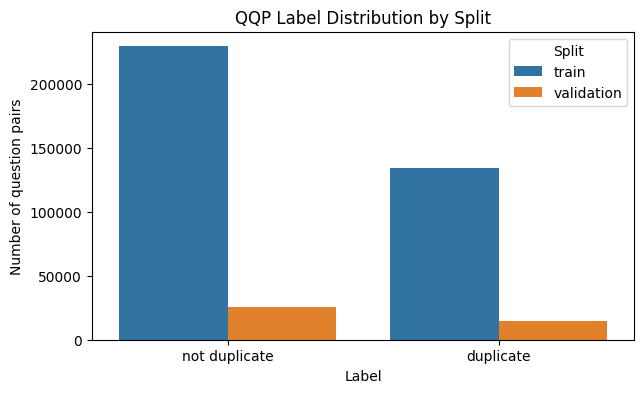

In [22]:
# Dataset overview and essential visualisations
label_names = {0: "not duplicate", 1: "duplicate"}
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Dataset object:")
print(ds)

print("\nAvailable splits:")
print(list(ds.keys()))

split_summary = pd.DataFrame({
    "split": list(ds.keys()),
    "rows": [len(ds[split]) for split in ds.keys()],
    "columns": [", ".join(ds[split].column_names) for split in ds.keys()]
})
display(split_summary)

print("\nTraining set columns:")
print(train_ds.column_names)

print("\nTraining set features:")
display(pd.DataFrame({
    "column": train_ds.column_names,
    "feature_type": [str(train_ds.features[column]) for column in train_ds.column_names]
}))

train_preview = train_ds.to_pandas()
eval_preview = eval_ds.to_pandas()

print("\nDataset table shapes:")
print(f"Training table: {train_preview.shape[0]:,} rows x {train_preview.shape[1]} columns")
print(f"Validation table: {eval_preview.shape[0]:,} rows x {eval_preview.shape[1]} columns")

print("\nFirst 10 training examples with all available columns:")
display(train_preview.head(10))

print("\nFirst 10 validation examples with all available columns:")
display(eval_preview.head(10))

label_summary = pd.DataFrame({
    "train_count": train_preview["label"].value_counts().sort_index(),
    "validation_count": eval_preview["label"].value_counts().sort_index()
}).rename(index=label_names)
label_summary["train_percent"] = (label_summary["train_count"] / len(train_preview) * 100).round(2)
label_summary["validation_percent"] = (label_summary["validation_count"] / len(eval_preview) * 100).round(2)

print("\nLabel distribution:")
display(label_summary)

missing_summary = pd.DataFrame({
    "train_missing": train_preview.isna().sum(),
    "validation_missing": eval_preview.isna().sum()
})

print("\nMissing values:")
display(missing_summary)

plot_data = pd.concat([
    train_preview[["label"]].assign(split="train"),
    eval_preview[["label"]].assign(split="validation")
], ignore_index=True)
plot_data["label_name"] = plot_data["label"].map(label_names)

plt.figure(figsize=(7, 4))
sns.countplot(data=plot_data, x="label_name", hue="split")
plt.title("QQP Label Distribution by Split")
plt.xlabel("Label")
plt.ylabel("Number of question pairs")
plt.legend(title="Split")
plt.show()

### Task 1. What is the top-5 common NOUN in the question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 common NOUN in the questions. To find the part of speech, use NLTK's "Universal" tag set. You may need to use NLTK's `sent_tokenize` and `word_tokenize` to get words. The function returns a list that is descendingly sorted according to freqency, e.g. [(noun1, 22), (noun2, 10), ...].
<!-- To produce the correct results, the function must do this.  -->
Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use NLTK's part of speech tagger, using the "Universal" tagset.
- Use NLTK's `pos_tag_sents` instead of `pos_tag`.

Marking Criteria: 
- 2.5 marks for the correct codes and results of each column, namely question1 and question2 columns.




In [15]:
def top_5_common_nouns(questions):
    """Return the top-5 common NOUN tokens from one question column."""
    text = " ".join(question for question in questions if isinstance(question, str))
    sentences = sent_tokenize(text)
    tokenized_sentences = [word_tokenize(sentence) for sentence in sentences]
    tagged_sentences = nltk.pos_tag_sents(tokenized_sentences, tagset="universal")

    nouns = [token for sentence in tagged_sentences for token, tag in sentence if tag == "NOUN"]
    noun_counts = Counter(nouns)
    return noun_counts.most_common(5)


q1_top_5_nouns = top_5_common_nouns(q1_tr)
q2_top_5_nouns = top_5_common_nouns(q2_tr)

print("Top-5 common NOUN in question1:", q1_top_5_nouns)
print("Top-5 common NOUN in question2:", q2_top_5_nouns)

Top-5 common NOUN in question1: [('India', 11998), ('people', 11342), ('way', 7622), ('Quora', 7594), ('difference', 6641)]
Top-5 common NOUN in question2: [('India', 12804), ('people', 12094), ('way', 8529), ('Quora', 7889), ('life', 7098)]


### Task 2. What are the top-5 common stem 2-grams and non-stem 2-grams for question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 most frequent 2-grams (bigrams) of stemmed and non-stemmed tokens along with their normalized frequency from the question1 and question2 columns of the QQP dataset. The output should be in descending order of frequency, **with frequencies normalized by the total number of bigrams (rounded to 4 decimal places)**, e.g., `[(('what', 'is'), 0.0105), (('what', 'are'), 0.0053), ...]`.

<!-- To produce the correct results, the function must do this: -->

Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's Porter stemmer to get the root words.
- Round normalized frequency to 4 precision after the decimal point.
- When computing bigrams, do not consider words that are in different sentences. For example, if we have this text: `Sentence 1. And sentence 2.` the bigrams are: `('Sentence','1'), ('1','.'), ('.','And'), ('And','sentence')`, etc. Note that the following would not be a valid bigram, since the punctuation mark and the word "And" are in different sentences: `('.','And')`.

Marking Criteria: 
- 2.5 marks for the correct codes and restuls of each column, namely question1 and question2 columns.

In [17]:
def top_5_common_bigrams(questions, stem=False):
    """Return the top-5 2-grams with normalized frequencies for one question column."""
    stemmer = PorterStemmer()
    text = " ".join(question for question in questions if isinstance(question, str))
    sentences = sent_tokenize(text)
    all_bigrams = []

    for sentence in sentences:
        tokens = [token.lower() for token in word_tokenize(sentence)]
        if stem:
            tokens = [stemmer.stem(token) for token in tokens]
        all_bigrams.extend(bigrams(tokens))

    total_bigrams = len(all_bigrams)
    if total_bigrams == 0:
        return []

    bigram_counts = Counter(all_bigrams)
    return [(bigram, round(count / total_bigrams, 4)) for bigram, count in bigram_counts.most_common(5)]


q1_non_stem_bigrams = top_5_common_bigrams(q1_tr, stem=False)
q1_stem_bigrams = top_5_common_bigrams(q1_tr, stem=True)

q2_non_stem_bigrams = top_5_common_bigrams(q2_tr, stem=False)
q2_stem_bigrams = top_5_common_bigrams(q2_tr, stem=True)

print("Top-5 non-stem 2-grams in question1:", q1_non_stem_bigrams)
print("Top-5 stem 2-grams in question1:", q1_stem_bigrams)
print("Top-5 non-stem 2-grams in question2:", q2_non_stem_bigrams)
print("Top-5 stem 2-grams in question2:", q2_stem_bigrams)


Top-5 non-stem 2-grams in question1: [(('what', 'is'), 0.0128), (('is', 'the'), 0.0112), (('what', 'are'), 0.0102), (('how', 'do'), 0.0084), (('can', 'i'), 0.0067)]
Top-5 stem 2-grams in question1: [(('what', 'is'), 0.0128), (('is', 'the'), 0.0112), (('what', 'are'), 0.0102), (('how', 'do'), 0.0084), (('can', 'i'), 0.0067)]
Top-5 non-stem 2-grams in question2: [(('what', 'is'), 0.0123), (('is', 'the'), 0.0108), (('what', 'are'), 0.0098), (('how', 'do'), 0.0085), (('can', 'i'), 0.0068)]
Top-5 stem 2-grams in question2: [(('what', 'is'), 0.0123), (('is', 'the'), 0.0108), (('what', 'are'), 0.0098), (('how', 'do'), 0.0085), (('can', 'i'), 0.0068)]


### Task 3. Naïve Bayes Classifier (5.5 marks)

The QQR dataset contains pairs of questions with labels indicating whether the two questions are semantically duplicate (1) or not (0).

1. Using a Bag-of-Words representation, train a Naïve Bayes classifier to predict duplicates. (2 marks)

1. Report accuracy, precision, and recall on the test set. (1.5 marks)

1. Inspect your confusion matrix. Identify one type of error (false positive or false negative) that dominates. Suggest a possible reason for this pattern based on the dataset. (2 mark)

In [23]:
# From now on, you are allowed to use a subset of the dataset which requires less computing resources.
# Note that you have to use the same subset for the following coding tasks, which ensure fairness when comparing performance across different models.

Ntrain = 1000
Ntest = 100
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"].select(range(Ntrain))
eval_ds  = ds["validation"].select(range(Ntest))

In [24]:
# Prepare Bag-of-Words inputs for Naive Bayes
train_texts_nb = [
    f"{q1} {q2}" for q1, q2 in zip(train_ds["question1"], train_ds["question2"])
]
test_texts_nb = [
    f"{q1} {q2}" for q1, q2 in zip(eval_ds["question1"], eval_ds["question2"])
]

y_train_nb = np.array(train_ds["label"])
y_test_nb = np.array(eval_ds["label"])

print(f"Training examples: {len(train_texts_nb)}")
print(f"Test examples: {len(test_texts_nb)}")


Training examples: 1000
Test examples: 100


In [25]:
# Train Bag-of-Words Naive Bayes classifier
nb_model = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

nb_model.fit(train_texts_nb, y_train_nb)
y_pred_nb = nb_model.predict(test_texts_nb)


Naive Bayes metrics on test set:
Accuracy: 0.6600
Precision: 0.4286
Recall: 0.4000

Confusion matrix:


,predicted not duplicate,predicted duplicate
actual not duplicate,54,16
actual duplicate,18,12


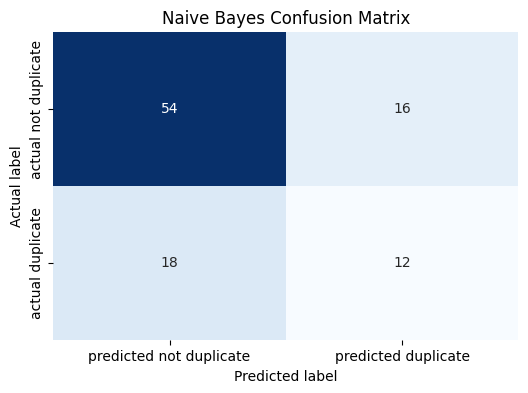

In [26]:
# Report accuracy, precision, recall, and confusion matrix
accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)
precision_nb = precision_score(y_test_nb, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test_nb, y_pred_nb, zero_division=0)

print("Naive Bayes metrics on test set:")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")

cm_nb = confusion_matrix(y_test_nb, y_pred_nb, labels=[0, 1])
cm_nb_df = pd.DataFrame(
    cm_nb,
    index=["actual not duplicate", "actual duplicate"],
    columns=["predicted not duplicate", "predicted duplicate"]
)

print("\nConfusion matrix:")
display(cm_nb_df)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Naive Bayes Confusion Matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()


In [27]:
# Inspect dominant error type
false_positives_nb = cm_nb[0, 1]
false_negatives_nb = cm_nb[1, 0]

print(f"False positives: {false_positives_nb}")
print(f"False negatives: {false_negatives_nb}")

if false_positives_nb > false_negatives_nb:
    dominant_error_nb = "false positives"
    error_reason_nb = (
        "False positives dominate. A likely reason is that some non-duplicate QQP "
        "question pairs share many keywords, so a Bag-of-Words Naive Bayes model may "
        "overestimate similarity even when the meanings differ."
    )
elif false_negatives_nb > false_positives_nb:
    dominant_error_nb = "false negatives"
    error_reason_nb = (
        "False negatives dominate. A likely reason is that some duplicate QQP "
        "question pairs use different wording, so a Bag-of-Words Naive Bayes model may "
        "miss semantic similarity when exact word overlap is low."
    )
else:
    dominant_error_nb = "equal false positives and false negatives"
    error_reason_nb = (
        "False positives and false negatives are equal. This reflects a limitation of "
        "Bag-of-Words features: they count token overlap but do not deeply model meaning."
    )

print(f"Dominant error type: {dominant_error_nb}")
print("Error analysis:", error_reason_nb)


False positives: 16
False negatives: 18
Dominant error type: false negatives
Error analysis: False negatives dominate. A likely reason is that some duplicate QQP question pairs use different wording, so a Bag-of-Words Naive Bayes model may miss semantic similarity when exact word overlap is low.


### Task 4. Siamese Neural Network (7 marks)

You now want to learn semantic similarity directly from the question pairs.

1. Design a Siamese Neural Network with two identical LSTM encoders that embed each question. (3 marks)

1. Use cosine similarity to classify duplicates, and report accuracy and F1-score. (2 marks)

1. Compare your Siamese model to your Naïve Bayes model. Which one handles imbalanced errors (precision vs. recall) better in your results, and why do you think that is? (2 marks)

**Note: Use the same reduced training and test subsets that you selected/used for Task 3.**

In [38]:
# Create a stratified train/validation split from the same reduced Task 3 training subset
siamese_random_state = 42
siamese_all_indices = np.arange(len(train_ds))
siamese_all_labels = np.array(train_ds["label"])

siamese_train_indices, siamese_val_indices = train_test_split(
    siamese_all_indices,
    test_size=0.2,
    random_state=siamese_random_state,
    stratify=siamese_all_labels
)

siamese_train_ds = train_ds.select(siamese_train_indices.tolist())
siamese_val_ds = train_ds.select(siamese_val_indices.tolist())
siamese_test_ds = eval_ds

print(f"Siamese training examples: {len(siamese_train_ds)}")
print(f"Siamese threshold-validation examples: {len(siamese_val_ds)}")
print(f"Siamese test examples: {len(siamese_test_ds)}")
print("Training label distribution:", Counter(siamese_train_ds["label"]))
print("Validation label distribution:", Counter(siamese_val_ds["label"]))
print("Test label distribution:", Counter(siamese_test_ds["label"]))


Siamese training examples: 800
Siamese threshold-validation examples: 200
Siamese test examples: 100
Training label distribution: Counter({0: 518, 1: 282})
Validation label distribution: Counter({0: 130, 1: 70})
Test label distribution: Counter({0: 70, 1: 30})


In [39]:
# Build vocabulary from the Siamese training split only and encode questions
PAD_IDX = 0
UNK_IDX = 1
max_len = 30
min_freq = 1

torch.manual_seed(siamese_random_state)
np.random.seed(siamese_random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(siamese_random_state)


def tokenize_question(question):
    """Tokenize one question using NLTK word_tokenize after lowercasing."""
    return word_tokenize(str(question).lower())


token_counts = Counter()
for question in list(siamese_train_ds["question1"]) + list(siamese_train_ds["question2"]):
    token_counts.update(tokenize_question(question))

vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
for token, count in token_counts.most_common():
    if count >= min_freq:
        vocab[token] = len(vocab)


def encode_question(question, vocab, max_len):
    tokens = tokenize_question(question)
    token_ids = [vocab.get(token, UNK_IDX) for token in tokens]

    if len(token_ids) == 0:
        token_ids = [UNK_IDX]

    length = min(len(token_ids), max_len)
    padded_ids = token_ids[:max_len] + [PAD_IDX] * max(0, max_len - len(token_ids))
    return padded_ids, length


print(f"Vocabulary size: {len(vocab)}")
print(f"Maximum sequence length: {max_len}")


Vocabulary size: 3495
Maximum sequence length: 30


In [40]:
# Create PyTorch datasets and dataloaders for Siamese question pairs
class QQPPairDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len):
        self.q1 = list(hf_dataset["question1"])
        self.q2 = list(hf_dataset["question2"])
        self.labels = np.array(hf_dataset["label"], dtype=np.float32)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        q1_ids, q1_len = encode_question(self.q1[index], self.vocab, self.max_len)
        q2_ids, q2_len = encode_question(self.q2[index], self.vocab, self.max_len)

        return {
            "q1_ids": torch.tensor(q1_ids, dtype=torch.long),
            "q1_len": torch.tensor(q1_len, dtype=torch.long),
            "q2_ids": torch.tensor(q2_ids, dtype=torch.long),
            "q2_len": torch.tensor(q2_len, dtype=torch.long),
            "label": torch.tensor(self.labels[index], dtype=torch.float32)
        }


batch_size = 32

generator = torch.Generator()
generator.manual_seed(siamese_random_state)

siamese_train_dataset = QQPPairDataset(siamese_train_ds, vocab, max_len)
siamese_val_dataset = QQPPairDataset(siamese_val_ds, vocab, max_len)
siamese_test_dataset = QQPPairDataset(siamese_test_ds, vocab, max_len)

siamese_train_loader = DataLoader(
    siamese_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator
)
siamese_val_loader = DataLoader(siamese_val_dataset, batch_size=batch_size, shuffle=False)
siamese_test_loader = DataLoader(siamese_test_dataset, batch_size=batch_size, shuffle=False)


In [41]:
# Define Siamese LSTM with one shared encoder for both questions
class SiameseLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)

    def encode(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        encoded = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.dropout(encoded)

    def forward(self, q1_ids, q1_lengths, q2_ids, q2_lengths):
        q1_vector = self.encode(q1_ids, q1_lengths)
        q2_vector = self.encode(q2_ids, q2_lengths)
        return q1_vector, q2_vector


In [47]:
# Train the Siamese LSTM with cosine embedding loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

embedding_dim = 128
hidden_dim = 64
learning_rate = 1e-3
dropout = 0.3
epochs = 10

siamese_model = SiameseLSTM(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    dropout=dropout
).to(device)

criterion = nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(siamese_model.parameters(), lr=learning_rate)

for epoch in range(1, epochs + 1):
    siamese_model.train()
    total_loss = 0.0

    for batch in siamese_train_loader:
        q1_ids = batch["q1_ids"].to(device)
        q1_lengths = batch["q1_len"].to(device)
        q2_ids = batch["q2_ids"].to(device)
        q2_lengths = batch["q2_len"].to(device)
        labels = batch["label"].to(device)

        cosine_targets = labels * 2 - 1

        optimizer.zero_grad()
        q1_vector, q2_vector = siamese_model(q1_ids, q1_lengths, q2_ids, q2_lengths)
        loss = criterion(q1_vector, q2_vector, cosine_targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(siamese_model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

    average_loss = total_loss / len(siamese_train_dataset)
    print(f"Epoch {epoch:02d}/{epochs} - Loss: {average_loss:.4f}")


Device: cuda
Epoch 01/20 - Loss: 0.4064
Epoch 02/20 - Loss: 0.3470
Epoch 03/20 - Loss: 0.3197
Epoch 04/20 - Loss: 0.2918
Epoch 05/20 - Loss: 0.2768
Epoch 06/20 - Loss: 0.2557
Epoch 07/20 - Loss: 0.2506
Epoch 08/20 - Loss: 0.2347
Epoch 09/20 - Loss: 0.2232
Epoch 10/20 - Loss: 0.2105
Epoch 11/20 - Loss: 0.2009
Epoch 12/20 - Loss: 0.1938
Epoch 13/20 - Loss: 0.1828
Epoch 14/20 - Loss: 0.1747
Epoch 15/20 - Loss: 0.1647
Epoch 16/20 - Loss: 0.1633
Epoch 17/20 - Loss: 0.1550
Epoch 18/20 - Loss: 0.1515
Epoch 19/20 - Loss: 0.1470
Epoch 20/20 - Loss: 0.1455


Selected cosine threshold: 0.07
Validation F1 at selected threshold: 0.5462

Siamese LSTM metrics on test set:
Accuracy: 0.3900
Precision: 0.3133
Recall: 0.8667
F1-score: 0.4602

Siamese confusion matrix:


,predicted not duplicate,predicted duplicate
actual not duplicate,13,57
actual duplicate,4,26


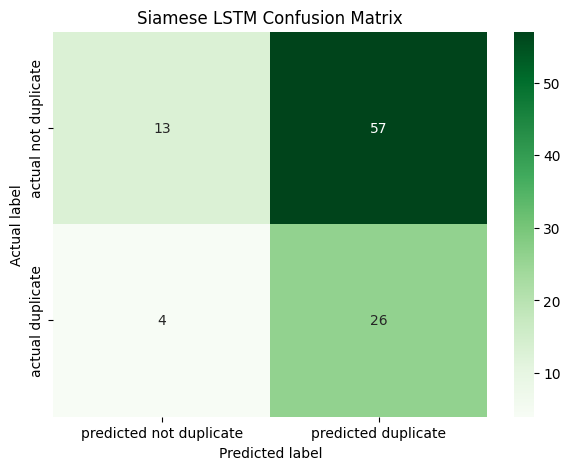

In [48]:
# Select cosine threshold on the validation split, then evaluate once on the test set
def collect_siamese_scores(model, data_loader):
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            q1_ids = batch["q1_ids"].to(device)
            q1_lengths = batch["q1_len"].to(device)
            q2_ids = batch["q2_ids"].to(device)
            q2_lengths = batch["q2_len"].to(device)

            q1_vector, q2_vector = model(q1_ids, q1_lengths, q2_ids, q2_lengths)
            similarities = nn.functional.cosine_similarity(q1_vector, q2_vector)

            all_scores.extend(similarities.cpu().numpy())
            all_labels.extend(batch["label"].numpy().astype(int))

    return np.array(all_scores), np.array(all_labels)


val_scores_siamese, y_val_siamese = collect_siamese_scores(siamese_model, siamese_val_loader)
test_scores_siamese, y_test_siamese = collect_siamese_scores(siamese_model, siamese_test_loader)

threshold_candidates = np.linspace(-1.0, 1.0, 201)
best_threshold = 0.0
best_val_f1 = -1.0
best_val_gap = float("inf")

for threshold in threshold_candidates:
    val_predictions = (val_scores_siamese >= threshold).astype(int)
    val_f1 = f1_score(y_val_siamese, val_predictions, zero_division=0)
    val_precision = precision_score(y_val_siamese, val_predictions, zero_division=0)
    val_recall = recall_score(y_val_siamese, val_predictions, zero_division=0)
    val_gap = abs(val_precision - val_recall)

    if val_f1 > best_val_f1 or (np.isclose(val_f1, best_val_f1) and val_gap < best_val_gap):
        best_val_f1 = val_f1
        best_val_gap = val_gap
        best_threshold = threshold

y_pred_siamese = (test_scores_siamese >= best_threshold).astype(int)

accuracy_siamese = accuracy_score(y_test_siamese, y_pred_siamese)
precision_siamese = precision_score(y_test_siamese, y_pred_siamese, zero_division=0)
recall_siamese = recall_score(y_test_siamese, y_pred_siamese, zero_division=0)
f1_siamese = f1_score(y_test_siamese, y_pred_siamese, zero_division=0)
cm_siamese = confusion_matrix(y_test_siamese, y_pred_siamese, labels=[0, 1])

print(f"Selected cosine threshold: {best_threshold:.2f}")
print(f"Validation F1 at selected threshold: {best_val_f1:.4f}")
print("\nSiamese LSTM metrics on test set:")
print(f"Accuracy: {accuracy_siamese:.4f}")
print(f"Precision: {precision_siamese:.4f}")
print(f"Recall: {recall_siamese:.4f}")
print(f"F1-score: {f1_siamese:.4f}")

cm_siamese_df = pd.DataFrame(
    cm_siamese,
    index=["actual not duplicate", "actual duplicate"],
    columns=["predicted not duplicate", "predicted duplicate"]
)

print("\nSiamese confusion matrix:")
display(cm_siamese_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_siamese_df, annot=True, fmt="d", cmap="Greens")
plt.title("Siamese LSTM Confusion Matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()


In [49]:
# Compare Siamese LSTM with Naive Bayes precision/recall balance
f1_nb = f1_score(y_test_nb, y_pred_nb, zero_division=0)

comparison_df = pd.DataFrame([
    {
        "model": "Naive Bayes",
        "accuracy": accuracy_nb,
        "precision": precision_nb,
        "recall": recall_nb,
        "f1": f1_nb,
        "precision_recall_gap": abs(precision_nb - recall_nb)
    },
    {
        "model": "Siamese LSTM",
        "accuracy": accuracy_siamese,
        "precision": precision_siamese,
        "recall": recall_siamese,
        "f1": f1_siamese,
        "precision_recall_gap": abs(precision_siamese - recall_siamese)
    }
]).round(4)

display(comparison_df)

nb_gap = comparison_df.loc[comparison_df["model"] == "Naive Bayes", "precision_recall_gap"].iloc[0]
siamese_gap = comparison_df.loc[comparison_df["model"] == "Siamese LSTM", "precision_recall_gap"].iloc[0]
gap_difference = abs(nb_gap - siamese_gap)

if gap_difference <= 0.02:
    comparison_text = (
        "Both models show similar precision-recall balance, but they make errors for "
        "different reasons. Naive Bayes relies on word overlap, while the Siamese model "
        "tries to learn question representations from limited data."
    )
elif siamese_gap < nb_gap:
    comparison_text = (
        "The Siamese LSTM handles the precision-recall imbalance better because its gap "
        "is smaller. This suggests that learning paired question representations with an "
        "LSTM and cosine similarity helped balance duplicate and non-duplicate predictions."
    )
else:
    comparison_text = (
        "Naive Bayes handles the precision-recall imbalance better in these results. The "
        "Siamese LSTM may require more data to learn reliable semantic similarity, because "
        "it is trained from scratch on only 1000 examples."
    )

print("Comparison:", comparison_text)


,model,accuracy,precision,recall,f1,precision_recall_gap
0,Naive Bayes,0.66,0.4286,0.4000,0.4138,0.0286
1,Siamese LSTM,0.39,0.3133,0.8667,0.4602,0.5534


Comparison: Naive Bayes handles the precision-recall imbalance better in these results. The Siamese LSTM may require more data to learn reliable semantic similarity, because it is trained from scratch on only 1000 examples.


### Task 5. Transformer-Based Classifier (10 marks)

Instead of handcrafted features or LSTMs, you now fine-tune a pre-trained Transformer (e.g., BERT or RoBERTa, etc) for QQP.

1. Fine-tune the model for 3 epochs with learning rate 2e-5. (3 marks)

1. Report the accuracy, precision, recall, and F1-score. (2 marks)

1. Compare your Transformer results with your Siamese model. Did the Transformer improve both precision and recall, or mainly one? What does this suggest about how it captures question meaning? (2 marks)

1. Look at one example your Transformer misclassified. Write a short explanation of why the model might have made this mistake. (3 marks)

**Note: Use the same reduced training and test subsets that you selected/used for Task 3.**

In [51]:
# Load Transformer tokenizer
transformer_model_name = "bert-base-uncased"

if "Ntrain" not in globals() or "Ntest" not in globals():
    raise NameError("Run the Task 3 subset cell before Task 5 so Ntrain and Ntest are defined.")
assert len(train_ds) == Ntrain and len(eval_ds) == Ntest, "Run the Task 3 subset cell before Task 5."

print("Transformer model:", transformer_model_name)
print(f"Training examples: {len(train_ds)}")
print(f"Test examples: {len(eval_ds)}")

transformer_tokenizer = AutoTokenizer.from_pretrained(transformer_model_name)

Transformer model: bert-base-uncased
Training examples: 1000
Test examples: 100


In [52]:
# Tokenize QQP question pairs for Transformer fine-tuning
def tokenize_transformer_pairs(batch):
    return transformer_tokenizer(
        batch["question1"],
        batch["question2"],
        truncation=True
    )


tokenized_train_ds = train_ds.map(tokenize_transformer_pairs, batched=True)
tokenized_eval_ds = eval_ds.map(tokenize_transformer_pairs, batched=True)

if "label" in tokenized_train_ds.column_names:
    tokenized_train_ds = tokenized_train_ds.rename_column("label", "labels")
if "label" in tokenized_eval_ds.column_names:
    tokenized_eval_ds = tokenized_eval_ds.rename_column("label", "labels")

columns_to_remove_train = [
    column for column in ["question1", "question2", "idx"]
    if column in tokenized_train_ds.column_names
]
columns_to_remove_eval = [
    column for column in ["question1", "question2", "idx"]
    if column in tokenized_eval_ds.column_names
]

if columns_to_remove_train:
    tokenized_train_ds = tokenized_train_ds.remove_columns(columns_to_remove_train)
if columns_to_remove_eval:
    tokenized_eval_ds = tokenized_eval_ds.remove_columns(columns_to_remove_eval)

data_collator = DataCollatorWithPadding(tokenizer=transformer_tokenizer)

print("Tokenized training columns:", tokenized_train_ds.column_names)
print("Tokenized test columns:", tokenized_eval_ds.column_names)

Map: 100%|██████████| 100/100 [00:00<00:00, 4999.23 examples/s]

Tokenized training columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Tokenized test columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [53]:
# Load pre-trained Transformer classifier and define evaluation metrics
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    transformer_model_name,
    num_labels=2
)


def compute_transformer_metrics(eval_pred):
    logits = eval_pred.predictions if hasattr(eval_pred, "predictions") else eval_pred[0]
    labels = eval_pred.label_ids if hasattr(eval_pred, "label_ids") else eval_pred[1]
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0)
    }

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6858.11it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [54]:
# Fine-tune the Transformer for exactly 3 epochs with learning rate 2e-5
task5_epochs = 3
task5_learning_rate = 2e-5

training_args = TrainingArguments(
    output_dir="./task5_bert_qqp",
    learning_rate=task5_learning_rate,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=task5_epochs,
    weight_decay=0.01,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    seed=42,
    data_seed=42,
    do_train=True,
    do_eval=True
)

transformer_trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized_train_ds,
    eval_dataset=tokenized_eval_ds,
    data_collator=data_collator,
    processing_class=transformer_tokenizer,
    compute_metrics=compute_transformer_metrics
)

print(f"Fine-tuning for {task5_epochs} epochs with learning rate {task5_learning_rate}")
transformer_trainer.train()

Fine-tuning for 3 epochs with learning rate 2e-05


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.557773,0.565050,0.720000,0.545455,0.400000,0.461538
2,0.331285,0.550201,0.700000,0.500000,0.633333,0.558824
3,0.150864,0.625713,0.720000,0.526316,0.666667,0.588235


TrainOutput(global_step=375, training_loss=0.3466404724121094, metrics={'train_runtime': 15.1585, 'train_samples_per_second': 197.909, 'train_steps_per_second': 24.739, 'total_flos': 81654871586880.0, 'train_loss': 0.3466404724121094, 'epoch': 3.0})

Transformer metrics on test set:
Accuracy: 0.7200
Precision: 0.5263
Recall: 0.6667
F1-score: 0.5882

Transformer confusion matrix:


,predicted not duplicate,predicted duplicate
actual not duplicate,52,18
actual duplicate,10,20


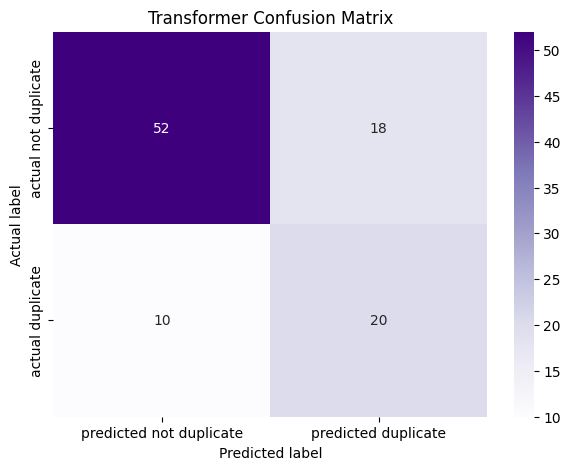

In [55]:
# Evaluate Transformer on the same reduced test subset used in Task 3
transformer_predictions = transformer_trainer.predict(tokenized_eval_ds)
transformer_logits = transformer_predictions.predictions

y_pred_transformer = np.argmax(transformer_logits, axis=1)
y_test_transformer = np.array(eval_ds["label"])

accuracy_transformer = accuracy_score(y_test_transformer, y_pred_transformer)
precision_transformer = precision_score(y_test_transformer, y_pred_transformer, zero_division=0)
recall_transformer = recall_score(y_test_transformer, y_pred_transformer, zero_division=0)
f1_transformer = f1_score(y_test_transformer, y_pred_transformer, zero_division=0)

print("Transformer metrics on test set:")
print(f"Accuracy: {accuracy_transformer:.4f}")
print(f"Precision: {precision_transformer:.4f}")
print(f"Recall: {recall_transformer:.4f}")
print(f"F1-score: {f1_transformer:.4f}")

cm_transformer = confusion_matrix(y_test_transformer, y_pred_transformer, labels=[0, 1])
cm_transformer_df = pd.DataFrame(
    cm_transformer,
    index=["actual not duplicate", "actual duplicate"],
    columns=["predicted not duplicate", "predicted duplicate"]
)

print("\nTransformer confusion matrix:")
display(cm_transformer_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_transformer_df, annot=True, fmt="d", cmap="Purples")
plt.title("Transformer Confusion Matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

In [56]:
# Compare Transformer with Siamese LSTM
transformer_vs_siamese_df = pd.DataFrame([
    {
        "model": "Siamese LSTM",
        "accuracy": accuracy_siamese,
        "precision": precision_siamese,
        "recall": recall_siamese,
        "f1": f1_siamese
    },
    {
        "model": "Transformer BERT",
        "accuracy": accuracy_transformer,
        "precision": precision_transformer,
        "recall": recall_transformer,
        "f1": f1_transformer
    }
]).round(4)

display(transformer_vs_siamese_df)

precision_change = precision_transformer - precision_siamese
recall_change = recall_transformer - recall_siamese

print(
    f"Transformer precision changed by {precision_change:.4f} "
    f"and recall changed by {recall_change:.4f} compared with the Siamese LSTM."
)

if precision_change > 0 and recall_change > 0:
    transformer_comparison_text = (
        "The Transformer improved both precision and recall. This suggests that the "
        "pre-trained contextual representation captured question meaning better than "
        "the LSTM trained from scratch on the small subset."
    )
elif precision_change > 0 and recall_change <= 0:
    transformer_comparison_text = (
        "The Transformer mainly improved precision, so it was more careful when "
        "predicting duplicate pairs. This suggests the pre-trained model reduced some "
        "false positives by using contextual meaning rather than only surface similarity."
    )
elif precision_change <= 0 and recall_change > 0:
    transformer_comparison_text = (
        "The Transformer mainly improved recall, so it found more duplicate pairs. "
        "This suggests it captured more semantic similarity, although it may still "
        "over-predict duplicates if precision did not also improve."
    )
else:
    transformer_comparison_text = (
        "The Transformer did not improve precision or recall in these results. A likely "
        "reason is that the reduced training subset is small, so fine-tuning may be unstable."
    )

print("Comparison:", transformer_comparison_text)

,model,accuracy,precision,recall,f1
0,Siamese LSTM,0.39,0.3133,0.8667,0.4602
1,Transformer BERT,0.72,0.5263,0.6667,0.5882


Transformer precision changed by 0.2131 and recall changed by -0.2000 compared with the Siamese LSTM.
Comparison: The Transformer mainly improved precision, so it was more careful when predicting duplicate pairs. This suggests the pre-trained model reduced some false positives by using contextual meaning rather than only surface similarity.


In [57]:
# Inspect one Transformer misclassified example
misclassified_indices = np.where(y_pred_transformer != y_test_transformer)[0]


def duplicate_label_text(label):
    return "duplicate (1)" if int(label) == 1 else "not duplicate (0)"


def lexical_overlap_ratio(question1, question2):
    q1_tokens = {
        token.lower() for token in word_tokenize(str(question1))
        if any(character.isalnum() for character in token)
    }
    q2_tokens = {
        token.lower() for token in word_tokenize(str(question2))
        if any(character.isalnum() for character in token)
    }

    if not q1_tokens or not q2_tokens:
        return 0.0
    return len(q1_tokens & q2_tokens) / min(len(q1_tokens), len(q2_tokens))


if len(misclassified_indices) == 0:
    print("No Transformer misclassified examples were found in this 100-example test subset.")
else:
    misclassified_index = int(misclassified_indices[0])
    misclassified_example = eval_ds[misclassified_index]
    q1_example = misclassified_example["question1"]
    q2_example = misclassified_example["question2"]
    true_label = int(y_test_transformer[misclassified_index])
    predicted_label = int(y_pred_transformer[misclassified_index])
    overlap = lexical_overlap_ratio(q1_example, q2_example)

    print("Misclassified example index:", misclassified_index)
    print("Question 1:", q1_example)
    print("Question 2:", q2_example)
    print("True label:", duplicate_label_text(true_label))
    print("Predicted label:", duplicate_label_text(predicted_label))
    print(f"Lexical overlap ratio: {overlap:.2f}")

    if true_label == 0 and predicted_label == 1:
        if overlap >= 0.5:
            mistake_explanation = (
                "This is a false positive. The two questions share many words, so the "
                "model may have focused on lexical and topical similarity even though "
                "the intended meanings are different."
            )
        else:
            mistake_explanation = (
                "This is a false positive. The pair may discuss a similar topic, and the "
                "model may have treated topical relatedness as semantic duplication."
            )
    elif true_label == 1 and predicted_label == 0:
        if overlap < 0.5:
            mistake_explanation = (
                "This is a false negative. The duplicate questions use different wording, "
                "so the model may not have connected the paraphrase strongly enough after "
                "fine-tuning on only 1000 examples."
            )
        else:
            mistake_explanation = (
                "This is a false negative. Even with shared words, small wording changes "
                "or ambiguity in QQP may have made the model judge the meanings as different."
            )
    else:
        mistake_explanation = (
            "This example is difficult because QQP questions can be short, informal, and "
            "ambiguous, so the duplicate boundary is sometimes unclear."
        )

    print("Explanation:", mistake_explanation)

Misclassified example index: 4
Question 1: What are some good baby girl names starting with D?
Question 2: What are some good baby girl names starting with D or H?
True label: not duplicate (0)
Predicted label: duplicate (1)
Lexical overlap ratio: 1.00
Explanation: This is a false positive. The two questions share many words, so the model may have focused on lexical and topical similarity even though the intended meanings are different.
